# 02 — Exploratory Data Analysis (EDA)
We explore the Ogun weather dataset: structure, summaries, trends, and relationships. All plots are saved under `visuals/`.

In [1]:
# Setup path and imports
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd()))
if PROJECT_ROOT not in sys.path: sys.path.append(PROJECT_ROOT)
# Add parent directory (which contains src) to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import PROCESSED_DIR
from src.visualize import save_current_fig
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

In [2]:
# Load processed dataset
df = pd.read_csv(PROCESSED_DIR / 'clean_weather.csv', parse_dates=[0], index_col=0)
df.head()

,temperature_c,humidity_pct,wind_speed_mps,precipitation_mm,surface_pressure_hpa,temperature_c_lag1,humidity_pct_lag1,wind_speed_mps_lag1,precipitation_mm_lag1,surface_pressure_hpa_lag1,month,day,weekday
date,,,,,,,,,,,,,
2015-01-02 00:00:00+01:00,27.583333,66.708333,5.304167,0.0,10.008292,28.013043,53.521739,5.821739,0.0,10.001043,1,2,4
2015-01-03 00:00:00+01:00,28.266667,62.791667,5.458333,0.0,10.021000,27.583333,66.708333,5.304167,0.0,10.008292,1,3,5
2015-01-04 00:00:00+01:00,27.716667,44.041667,6.500000,0.0,10.026333,28.266667,62.791667,5.458333,0.0,10.021000,1,4,6
2015-01-05 00:00:00+01:00,26.291667,28.291667,6.079167,0.0,10.018958,27.716667,44.041667,6.500000,0.0,10.026333,1,5,0
2015-01-06 00:00:00+01:00,25.662500,33.708333,5.983333,0.0,10.011208,26.291667,28.291667,6.079167,0.0,10.018958,1,6,1


In [3]:
# Ensure processed dataset exists; if not, run preprocessing
import os
from src.utils import PROCESSED_DIR
from src.preprocess import load_raw, preprocess, save_processed

proc_path = PROCESSED_DIR / 'clean_weather.csv'
if not os.path.exists(proc_path):
    try:
        df_raw = load_raw()
        df_proc = preprocess(df_raw)
        save_processed(df_proc)
        print('Processed dataset created at:', proc_path)
    except Exception as e:
        print('Could not create processed dataset automatically:', e)

## a) Data Collection Summary
- Source: Open-Meteo Historical Weather API (ERA5).
- Rationale: Free, reliable, and globally comprehensive, suitable for Abeokuta.
- The dataset includes daily aggregates of temperature, humidity, wind speed, precipitation, and surface pressure.

In [4]:
# Shape, columns, dtypes
df_shape = df.shape
df_cols = df.columns.tolist()
df_dtypes = df.dtypes
print('Shape:', df_shape)
print('Columns:', df_cols)
df_dtypes

Shape: (3961, 13)
Columns: ['temperature_c', 'humidity_pct', 'wind_speed_mps', 'precipitation_mm', 'surface_pressure_hpa', 'temperature_c_lag1', 'humidity_pct_lag1', 'wind_speed_mps_lag1', 'precipitation_mm_lag1', 'surface_pressure_hpa_lag1', 'month', 'day', 'weekday']


temperature_c                float64
humidity_pct                 float64
wind_speed_mps               float64
precipitation_mm             float64
surface_pressure_hpa         float64
temperature_c_lag1           float64
humidity_pct_lag1            float64
wind_speed_mps_lag1          float64
precipitation_mm_lag1        float64
surface_pressure_hpa_lag1    float64
month                          int64
day                            int64
weekday                        int64
dtype: object

## b) Data Description
Variables: 
- `temperature_c`: daily mean temperature (°C)
- `humidity_pct`: daily mean relative humidity (%)
- `wind_speed_mps`: daily mean wind speed (m/s)
- `precipitation_mm`: daily total precipitation (mm)
- `surface_pressure_hpa`: daily mean surface pressure (hPa)
- lag features: previous day values for each numeric variable
- time features: `month`, `day`, `weekday`

In [5]:
# Summary stats
summary = df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
temperature_c,3961.0,26.883146,1.765357,23.150000,25.262500,26.941667,28.312500,31.470833
humidity_pct,3961.0,78.573466,12.227009,16.583333,74.250000,82.041667,86.500000,96.833333
wind_speed_mps,3961.0,7.388946,1.698439,2.754167,6.125000,7.175000,8.504167,14.787500
precipitation_mm,3961.0,2.892098,5.158813,0.000000,0.100000,0.900000,3.600000,108.900000
surface_pressure_hpa,3961.0,10.003981,0.017544,9.955167,9.991000,10.003208,10.016833,10.059542
temperature_c_lag1,3961.0,26.884058,1.765007,23.150000,25.262500,26.941667,28.312500,31.470833
humidity_pct_lag1,3961.0,78.563752,12.231624,16.583333,74.208333,82.041667,86.500000,96.833333
wind_speed_mps_lag1,3961.0,7.389507,1.697554,2.754167,6.125000,7.175000,8.504167,14.787500
precipitation_mm_lag1,3961.0,2.892098,5.158813,0.000000,0.100000,0.900000,3.600000,108.900000
surface_pressure_hpa_lag1,3961.0,10.003971,0.017534,9.955167,9.991000,10.003167,10.016833,10.059542


### Observation

- The dataset contains 3,961 daily records of weather data for Abeokuta, Ogun State, sourced from the Open-Meteo Historical API (ERA5-based). The average temperature is 26.88°C, ranging from 23.15°C to 31.47°C, while the mean humidity is 78.57%, indicating a generally warm and humid climate.

- Average wind speed is 7.39 m/s, showing mild variation, and daily precipitation averages 2.89 mm, with occasional heavy rainfall (up to 108.9 mm). Surface pressure remains stable around 10.00 hPa with minimal fluctuation.

- Lag features closely match their original variables, confirming strong day-to-day continuity, while time features like month, day, and weekday help capture seasonal and temporal trends useful for short-term forecasting.

## c) Research Questions
1. How does temperature vary across months in Ogun State?
2. Is there a correlation between humidity and rainfall?
3. What period of the year experiences the highest wind speed?
4. Can we predict next-day temperature using past weather patterns?
5. How consistent are daily pressures throughout the year?

## d) Analysis Tasks

In [6]:
# Overall Summary: means, stds, ranges
overall = pd.DataFrame({
    'mean': df.mean(numeric_only=True),
    'std': df.std(numeric_only=True),
    'min': df.min(numeric_only=True),
    'max': df.max(numeric_only=True),
})
overall

,mean,std,min,max
temperature_c,26.883146,1.765357,23.150000,31.470833
humidity_pct,78.573466,12.227009,16.583333,96.833333
wind_speed_mps,7.388946,1.698439,2.754167,14.787500
precipitation_mm,2.892098,5.158813,0.000000,108.900000
surface_pressure_hpa,10.003981,0.017544,9.955167,10.059542
temperature_c_lag1,26.884058,1.765007,23.150000,31.470833
humidity_pct_lag1,78.563752,12.231624,16.583333,96.833333
wind_speed_mps_lag1,7.389507,1.697554,2.754167,14.787500
precipitation_mm_lag1,2.892098,5.158813,0.000000,108.900000
surface_pressure_hpa_lag1,10.003971,0.017534,9.955167,10.059542


In [7]:
# Group Analysis by month
group_month = df.groupby('month').agg(['mean','std'])
group_month

temperature_c           humidity_pct            wind_speed_mps  \
               mean       std         mean        std           mean   
month                                                                  
1         28.487770  0.905798    59.547181  15.518102       6.945686   
2         29.194065  0.967623    66.625134  12.701818       7.644748   
3         28.651014  0.909871    76.321237   4.382060       8.986034   
4         28.141149  0.896620    78.841035   4.093544       8.695833   
5         27.220723  0.966802    82.547898   4.333543       7.474206   
6         25.658472  0.889794    86.306439   3.763862       7.101806   
7         24.923900  0.585514    86.193915   3.533807       8.086510   
8         24.696334  0.544204    85.577102   3.418453       8.434812   
9         24.981566  0.599125    87.435985   3.199290       6.741629   
10        25.691178  0.766858    87.187561   2.822231       5.828482   
11        27.156544  0.763022    80.808060   5.769291       6.148292   
12        28.080497  0.791504    63.821909  14.140230       6.390820   

                precipitation_mm           surface_pressure_hpa            \
            std             mean       std                 mean       std   
month                                                                       
1      1.328239         0.360882  1.581745             9.997506  0.011717   
2      1.446820         0.747910  2.003655             9.987951  0.011787   
3      1.633218         1.909971  3.536402             9.986047  0.011433   
4      1.514297         2.132424  3.244178             9.988194  0.010902   
5      1.407660         3.350733  4.411506            10.003816  0.012207   
6      1.325772         5.527576  5.934331            10.018924  0.011114   
7      1.543061         4.645161  5.774382            10.026254  0.009891   
8      1.749390         4.703226  6.731586            10.022968  0.011983   
9      1.304532         5.832424  8.508084            10.015849  0.009256   
10     1.120084         4.035484  5.469138            10.005789  0.009787   
11     0.991191         0.782295  1.661982             9.996247  0.010661   
12     0.971724         0.165806  0.786614             9.995574  0.010997   

       ... wind_speed_mps_lag1           precipitation_mm_lag1            \
       ...                mean       std                  mean       std   
month  ...                                                                 
1      ...            6.932270  1.326638              0.322941  1.489948   
2      ...            7.597615  1.422127              0.718328  1.980913   
3      ...            8.948363  1.667604              1.853079  3.409317   
4      ...            8.728005  1.515742              2.167576  3.390422   
5      ...            7.493426  1.414807              3.310850  4.401708   
6      ...            7.090934  1.319302              5.455758  5.866798   
7      ...            8.041471  1.532753              4.726979  5.838944   
8      ...            8.445638  1.730473              4.677126  6.744113   
9      ...            6.838662  1.389556              5.735758  8.458017   
10     ...            5.835276  1.106865              4.193842  5.553430   
11     ...            6.148525  1.003232              0.866557  1.802446   
12     ...            6.384247  0.967053              0.167097  0.786464   

      surface_pressure_hpa_lag1                  day             weekday  \
                           mean       std       mean       std      mean   
month                                                                      
1                      9.997594  0.011575  16.044118  8.933438  2.994118   
2                      9.988229  0.011820  14.639871  8.175823  2.996785   
3                      9.986133  0.011491  16.000000  8.957416  3.002933   
4                      9.987922  0.010766  15.500000  8.668586  3.006061   
5                     10.003217  0.012414  16.000000  8.957416  2.994135   
6                   

In [9]:
# Time Series resampling to weekly and monthly
weekly = df.resample('W').mean(numeric_only=True)
monthly = df.resample('M').mean(numeric_only=True)
weekly.head()

/tmp/ipykernel_4330/2807114356.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M').mean(numeric_only=True)


,temperature_c,humidity_pct,wind_speed_mps,precipitation_mm,surface_pressure_hpa,temperature_c_lag1,humidity_pct_lag1,wind_speed_mps_lag1,precipitation_mm_lag1,surface_pressure_hpa_lag1,month,day,weekday
date,,,,,,,,,,,,,
2015-01-04 00:00:00+01:00,27.855556,57.847222,5.754167,0.000000,10.018542,27.954348,61.007246,5.528080,0.000000,10.010112,1.000000,3.000000,5.0
2015-01-11 00:00:00+01:00,26.366667,31.744048,6.916071,0.000000,10.019804,26.675595,34.345238,6.932143,0.000000,10.019339,1.000000,8.000000,3.0
2015-01-18 00:00:00+01:00,26.670238,40.148810,6.598214,0.000000,10.011387,26.358929,34.369048,6.608333,0.000000,10.013518,1.000000,15.000000,3.0
2015-01-25 00:00:00+01:00,28.301786,71.714286,7.668452,0.242857,9.995280,28.343452,69.934524,7.354762,0.042857,9.999595,1.000000,22.000000,3.0
2015-02-01 00:00:00+01:00,28.060714,76.946429,7.629167,0.957143,9.995286,27.940476,77.214286,7.875595,1.142857,9.994036,1.142857,24.571429,3.0


In [10]:
monthly.head()

,temperature_c,humidity_pct,wind_speed_mps,precipitation_mm,surface_pressure_hpa,temperature_c_lag1,humidity_pct_lag1,wind_speed_mps_lag1,precipitation_mm_lag1,surface_pressure_hpa_lag1,month,day,weekday
date,,,,,,,,,,,,,
2015-01-31 00:00:00+01:00,27.369306,54.684722,7.071944,0.276667,10.007157,27.370851,53.877114,7.017808,0.210000,10.007100,1.0,16.5,3.100000
2015-02-28 00:00:00+01:00,28.216964,76.837798,7.981994,1.507143,9.988484,28.221726,76.938988,8.087798,1.539286,9.988778,2.0,14.5,3.000000
2015-03-31 00:00:00+01:00,28.026344,79.454301,8.122849,2.358065,9.983720,28.101344,79.021505,8.052957,2.074194,9.983462,3.0,16.0,2.935484
2015-04-30 00:00:00+01:00,27.777361,80.394444,7.970417,1.470000,9.994376,27.698333,80.652778,7.885278,1.760000,9.994968,4.0,15.5,2.966667
2015-05-31 00:00:00+01:00,27.056586,84.399194,7.735887,4.303226,10.000504,27.142608,84.057796,7.796505,4.174194,9.999780,5.0,16.0,3.193548


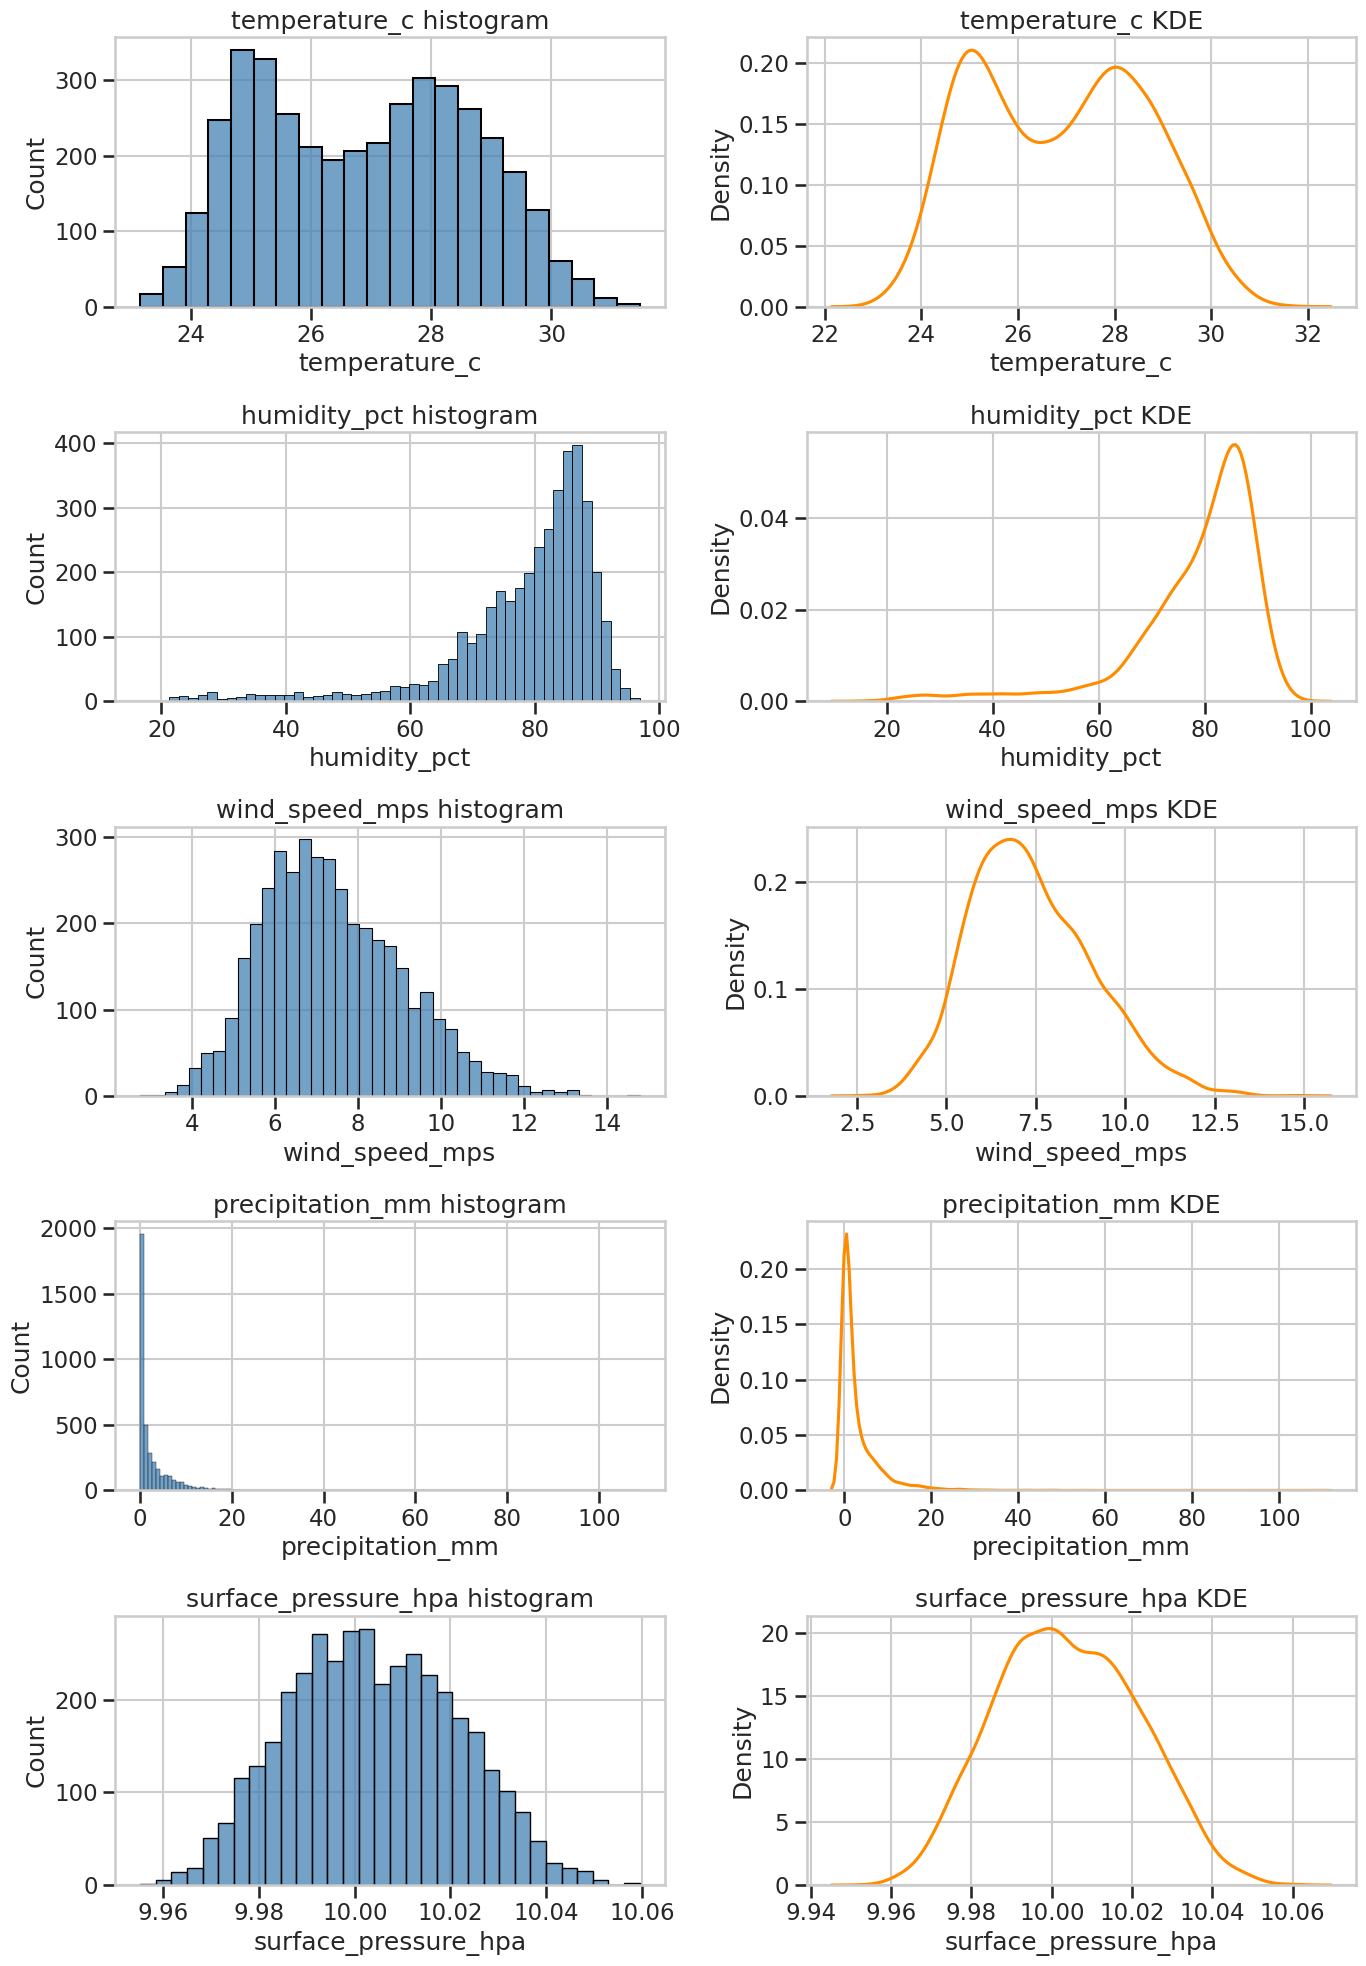

In [19]:
# Visualization of distributions: histograms and KDE
num_cols = ['temperature_c','humidity_pct','wind_speed_mps','precipitation_mm','surface_pressure_hpa']
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 4*len(num_cols)))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=False, ax=axes[i,0], color='steelblue')
    axes[i,0].set_title(f'{col} histogram')
    sns.kdeplot(df[col], ax=axes[i,1], color='darkorange')
    axes[i,1].set_title(f'{col} KDE')
save_current_fig('distributions_hist_kde.png')
plt.show()

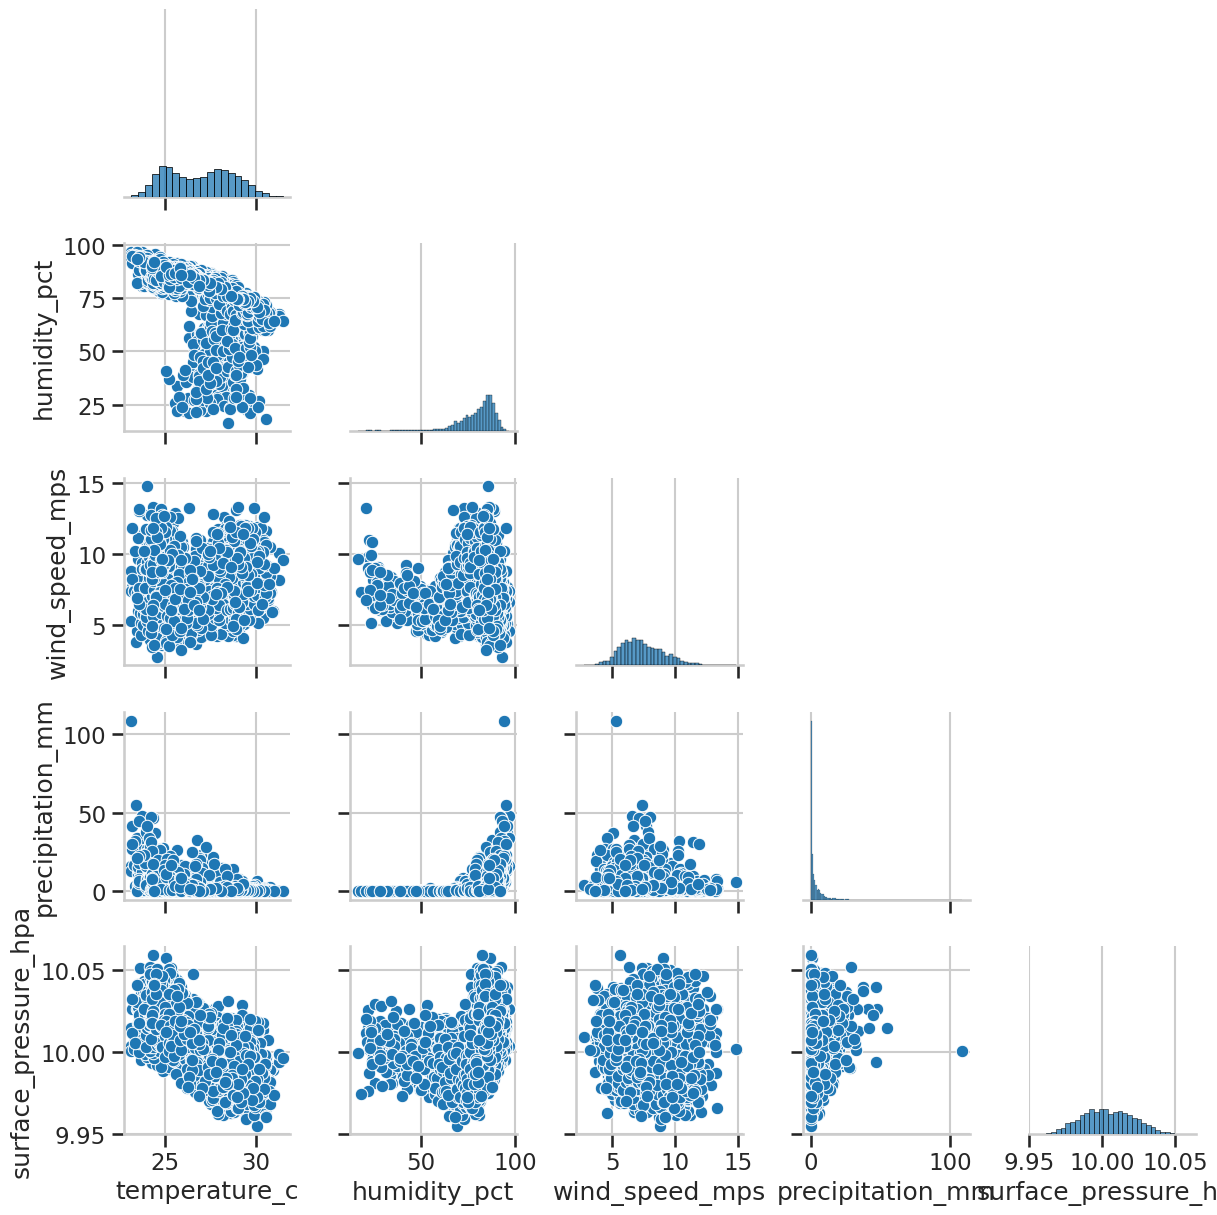

In [12]:
# Pairplot
sns.pairplot(df[num_cols].dropna(), corner=True, diag_kind='hist')
save_current_fig('pairplot_core_vars.png')
plt.show()

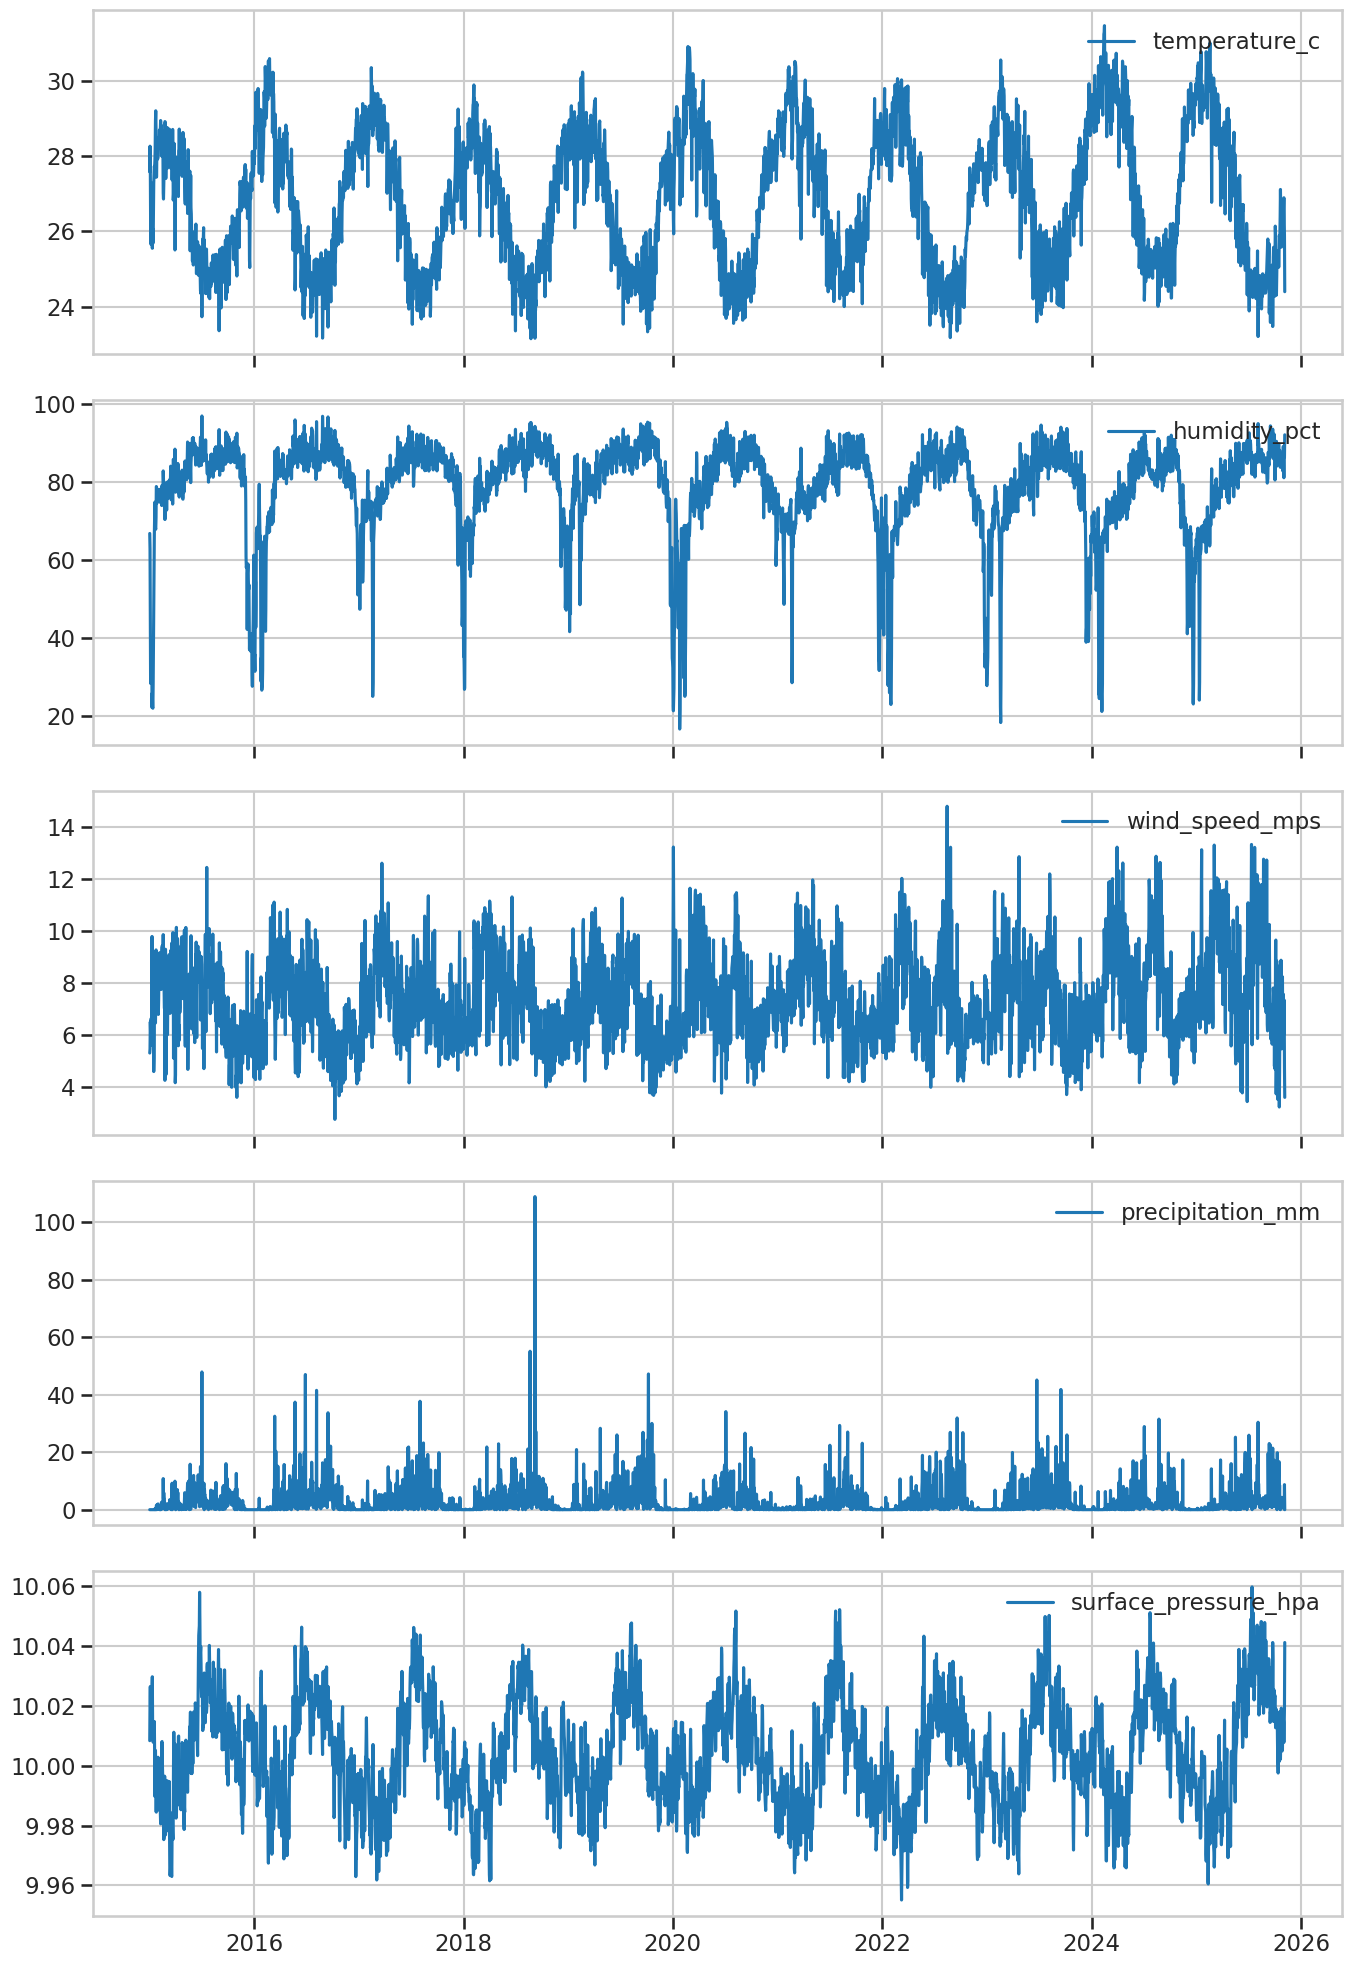

In [18]:
# Time Series Visualization: line charts for each variable
fig, axes = plt.subplots(len(num_cols), 1, figsize=(14, 4*len(num_cols)), sharex=True)
for i, col in enumerate(num_cols):
    axes[i].plot(df.index, df[col], label=col)
    axes[i].legend(loc='upper right')
save_current_fig('time_series_lines.png')
plt.show()

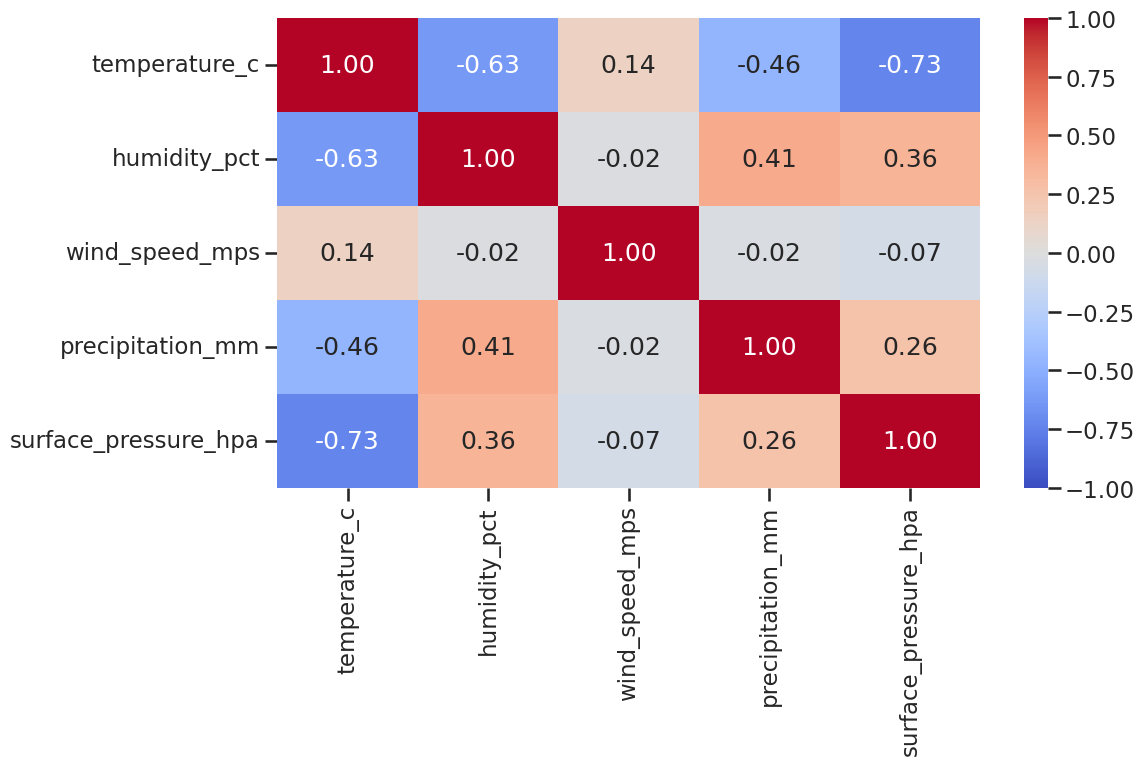

In [17]:
# Correlation heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
save_current_fig('correlation_heatmap.png')
plt.show()

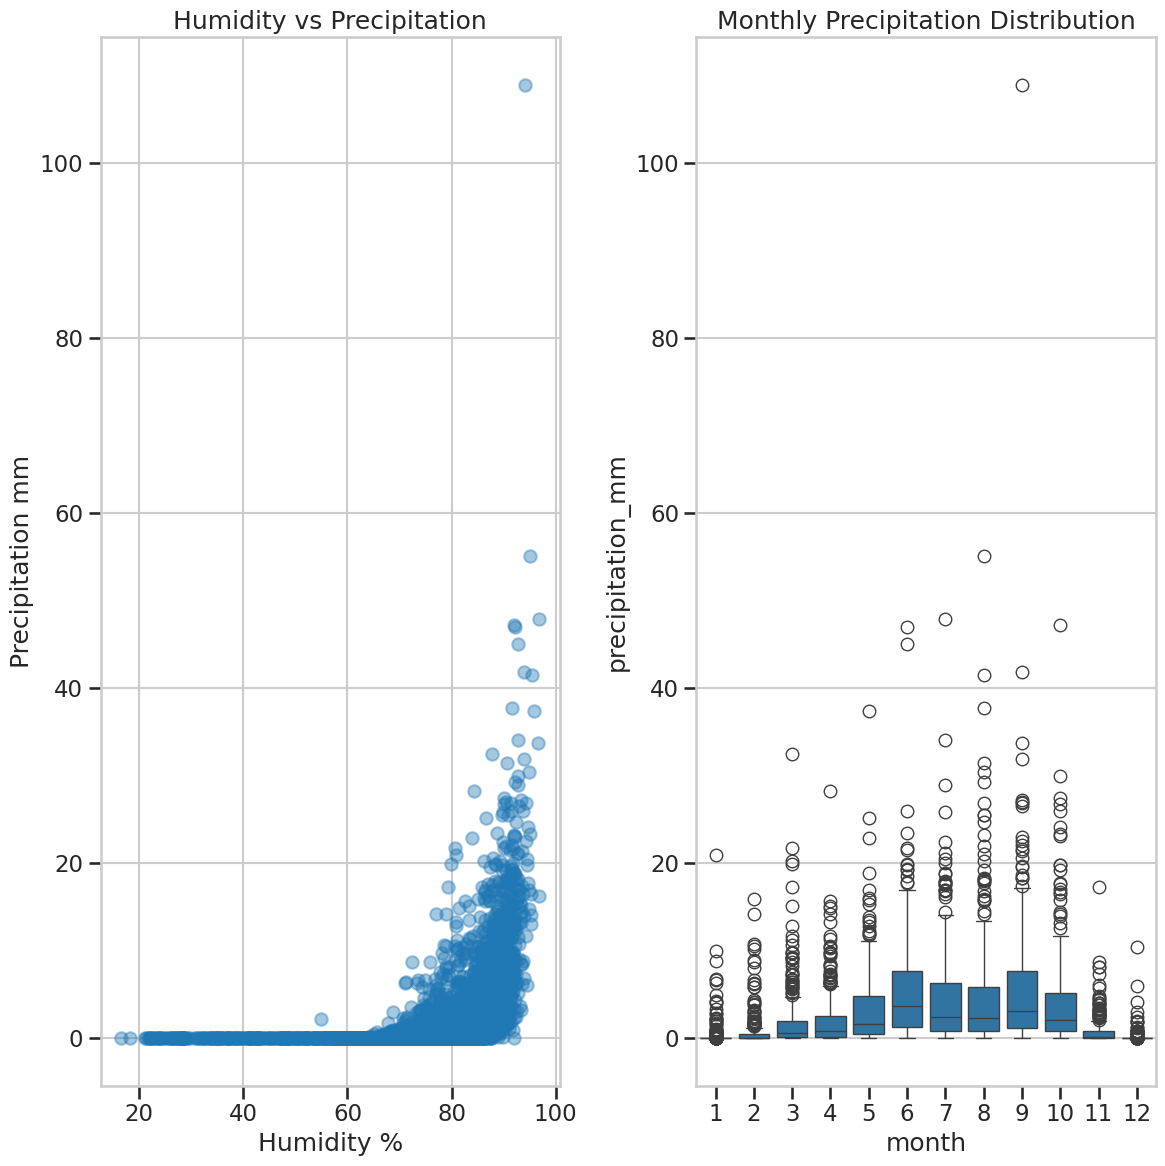

In [16]:
# Scatter: humidity vs precipitation; Boxplot rainfall by month
fig, ax = plt.subplots(1,2, figsize=(12,12))
ax[0].scatter(df['humidity_pct'], df['precipitation_mm'], alpha=0.4)
ax[0].set_xlabel('Humidity %')
ax[0].set_ylabel('Precipitation mm')
ax[0].set_title('Humidity vs Precipitation')
sns.boxplot(data=df, x='month', y='precipitation_mm', ax=ax[1])
ax[1].set_title('Monthly Precipitation Distribution')
save_current_fig('scatter_box_precipitation.png')
plt.show()